In [1]:
from google.colab import drive
import torch
import sys
import numpy as np
import math
import time
import torch.nn.functional as F
from transformers import get_cosine_schedule_with_warmup
drive.mount('/content/gdrive', force_remount=True)


base_dir = "/content/gdrive/MyDrive/Junior/Second Semester/CS 6787 - Advanced ML Systems/regen-gpt2"
# base_dir = "/content/gdrive/MyDrive/Final Project"
# base_dir = ""
sys.path.append(base_dir)

device = torch.device("cuda" if torch.cuda.is_available()
                else ("mps" if torch.backends.mps.is_available()
                else "cpu"))
#device = torch.device("meta")
print(F"Device set to {device}")
print("Loading GPT2 model...")

Mounted at /content/gdrive
Device set to cuda
Loading GPT2 model...


In [2]:
import sys
import os
import importlib
from Datasets.DataLoader import CombinedBinDataLoader
from Models.Lag_Behind_Model.Lag_Behind_Model import GPT2_Lag
from Models.Configs import LagBehindConfig, TrainConfig
from Models.Lag_Behind_Model.train_Lag_Behind import train_loop, estimate_loss

In [3]:
model_config = LagBehindConfig()
train_config = TrainConfig()
eff_batch_size = train_config.batch_per_iter * train_config.grad_acc_factor
tokens_per_step = eff_batch_size * model_config.block_size


model = GPT2_Lag(model_config, device)
model = model.to(device)
model = torch.compile(model)

optimizer = train_config.make_optimizer(model)
scheduler = train_config.make_scheduler(optimizer)
scaler = train_config.make_scaler()

get_lr = train_config.get_lr
torch.set_float32_matmul_precision('high')
save_path = f'/content/drive/MyDrive/checkpoint_step{num_steps_train}_{datetime.now():%Y%m%d_%H%M%S}.pt'


In [4]:
#Load the combined_bin dataset from drive and place it in Colab's files
!cp "/content/gdrive/MyDrive/Junior/Second Semester/CS 6787 - Advanced ML Systems/regen-gpt2/Datasets/fineweb_1B.bin" "/content/fineweb_1B.bin"
train_loader, val_loader = CombinedBinDataLoader.create_loaders(
    '/content/fineweb_1B.bin',
    train_config.batch_per_iter,
    model_config.block_size,
    train_config,
    seed=42
)

Initialized loader with 57,983 chunks of size 16385.
Initialized loader with 3,052 chunks of size 16385.


In [5]:
#Actually train the model
torch.cuda.empty_cache()
history = train_loop(model,
                     optimizer,
                     scheduler,
                     scaler,
                     device,
                     train_loader,
                     val_loader,
                     train_config,
                     model_config,
                     save_path)

Trainable parameters: 124,046,592


W0504 19:17:33.226000 4652 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Step    0 | Val FWD: 10.9916 | PPL: 59370.87 | Val BWD: 10.9922
step    0 | tokens 262,144 | lr 0.00e+00 | train loss 10.9915
step   10 | tokens 2,883,584 | lr 2.00e-05 | train loss 10.3856
step   20 | tokens 5,505,024 | lr 4.00e-05 | train loss 9.6050
step   30 | tokens 8,126,464 | lr 6.00e-05 | train loss 9.1408
step   40 | tokens 10,747,904 | lr 8.00e-05 | train loss 8.6614
step   50 | tokens 13,369,344 | lr 1.00e-04 | train loss 8.1949
step   60 | tokens 15,990,784 | lr 1.20e-04 | train loss 7.8042
step   70 | tokens 18,612,224 | lr 1.40e-04 | train loss 7.7471
step   80 | tokens 21,233,664 | lr 1.60e-04 | train loss 7.6354
step   90 | tokens 23,855,104 | lr 1.80e-04 | train loss 7.6835
Step  100 | Val FWD: 7.6390 | PPL: 2077.62 | Val BWD: 7.6972
step  100 | tokens 26,476,544 | lr 2.00e-04 | train loss 7.7457
step  110 | tokens 29,097,984 | lr 2.20e-04 | train loss 7.6441
step  120 | tokens 31,719,424 | lr 2.40e-04 | train loss 7.6953
step  130 | tokens 34,340,864 | lr 2.60e-04 | t

KeyboardInterrupt: 

In [ ]:
estimate_loss(model, val_loader, device, num_steps_val)

(5.413740158081055, 224.46957397460938, 4.669077396392822)

In [ ]:
lag_config = LagBehindConfig()
lag_model = GPT2_Lag(lag_config, device)
#below is an isoparameter model to vanilla
lag_ckpt  = torch.load('/content/drive/MyDrive/checkpoint_step3623_20260501_212524.pt',
                        map_location=device)
lag_model.load_state_dict(lag_ckpt['model_state_dict'])
lag_model.to(device)
lag_model.eval()

GPT2_Lag(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(512, 768)
    (h): ModuleList(
      (0-11): 12 x LayerBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): AttentionMultiHeadFused(
          (w_qkv): Linear(in_features=768, out_features=2304, bias=True)
          (output): Linear(in_features=768, out_features=768, bias=True)
          (resid_drop): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.1, inplace=False)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias

In [ ]:
vanilla_config = BaselineConfig()
vanilla_model = GPT2_Baseline(vanilla_config, device)
vanilla_model.to(device)
vanilla_model = torch.compile(vanilla_model)
vanilla_ckpt  = torch.load('/content/drive/MyDrive/ckpt_baseline_step_3623.pt',
                            map_location=device)
vanilla_model.load_state_dict(vanilla_ckpt['model_state_dict'])
vanilla_model.to(device)
vanilla_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

OptimizedModule(
  (_orig_mod): GPT2_Baseline(
    (transformer): ModuleDict(
      (wte): Embedding(50257, 768)
      (wpe): Embedding(512, 768)
      (h): ModuleList(
        (0-11): 12 x LayerBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): AttentionMultiHeadFused(
            (w_qkv): Linear(in_features=768, out_features=2304, bias=True)
            (output): Linear(in_features=768, out_features=768, bias=True)
            (resid_drop): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='tanh')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            (drop): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.1,

In [ ]:
test_data_sample = val_loader.get_data()
len(test_data_sample)

2

In [ ]:
@torch.no_grad()
def evaluate_next_token_correction(vanilla_model, lag_model, loader, device,
                                    prompt_len=50, num_prompts=100,
                                    temperature=1.0, top_k=50, both_lag = False):
    vanilla_model.eval()
    lag_model.eval()

    van_correct = 0
    lag_correct = 0
    corrections = 0
    loader.idx  = 0

    def sample(logits):
        if top_k is not None:
            threshold = torch.topk(logits, min(top_k, logits.size(-1))).values[-1]
            logits[logits < threshold] = float('-inf')
        return torch.multinomial(F.softmax(logits / temperature, dim=-1), 1).item()

    for _ in range(num_prompts):
        x, _ = loader.get_data()
        seq = x[0].tolist()

        prompt = seq[:prompt_len]
        target_next_token = seq[prompt_len-1]
        target_token_for_vanilla = seq[prompt_len]

        initial_prompt_tensor = torch.tensor(prompt, dtype=torch.long, device=device).unsqueeze(0)
        initial_prompt_tensor_repeat = initial_prompt_tensor.repeat(2, 1)
        if both_lag:
            logits, _, _ = vanilla_model(initial_prompt_tensor_repeat, initial_prompt_tensor_repeat)
        else:
            logits, _ = vanilla_model(initial_prompt_tensor, initial_prompt_tensor)
        autoregressive_gen_next_token = sample(logits[0, -1, :].clone())
        autoregressive_generated_next_token_tensor = torch.tensor([autoregressive_gen_next_token], dtype=torch.long, device=device)

        # updated_prompt_tensor = torch.cat([initial_prompt_tensor[0], autoregressive_generated_next_token_tensor]).unsqueeze(0)
        # logits, _ = vanilla_model(updated_prompt_tensor, updated_prompt_tensor)
        # autoregressive_gen_next_next_token = sample(logits[0, -1, :].clone())

        full_seq = torch.tensor(prompt + [autoregressive_gen_next_token],
                                 dtype=torch.long, device=device).unsqueeze(0)
        seq2 = full_seq.repeat(2, 1)
        _, logits_lag, _ = lag_model(seq2)

        next_token_corrected = sample(logits_lag[0, -1, :].clone())

        van_correct += int(autoregressive_gen_next_token == target_token_for_vanilla)
        lag_correct += int(next_token_corrected == target_next_token)
        #corrections += int(next_token_corrected != autoregressive_gen_next_token)

    print(f"Vanilla accuracy:  {van_correct}/{num_prompts} = {van_correct/num_prompts:.4f}")
    print(f"Lag accuracy:      {lag_correct}/{num_prompts} = {lag_correct/num_prompts:.4f}")
    print(f"Corrections made:  {corrections}/{num_prompts}")

    return van_correct, lag_correct, corrections

In [ ]:
evaluate_next_token_correction(vanilla_model, lag_model, val_loader, device, prompt_len=50, num_prompts=100, temperature=1.0, top_k=50)

Vanilla accuracy:  11/100 = 0.1100
Lag accuracy:      18/100 = 0.1800
Corrections made:  0/100


(11, 18, 0)

In [ ]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=500, num_prompts=100, temperature=1.0, top_k=50)

Vanilla accuracy:  11/100 = 0.1100
Lag accuracy:      17/100 = 0.1700
Corrections made:  0/100


(11, 17, 0)

In [ ]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=500, num_prompts=100, temperature=1.0, top_k=1)

Vanilla accuracy:  20/100 = 0.2000
Lag accuracy:      25/100 = 0.2500
Corrections made:  0/100


(20, 25, 0)

In [ ]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=100, num_prompts=2000, temperature=1.0, top_k=1)

/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Vanilla accuracy:  418/2000 = 0.2090
Lag accuracy:      552/2000 = 0.2760
Corrections made:  0/2000


(418, 552, 0)

In [ ]:
evaluate_next_token_correction(lag_model, lag_model, test_loader, device, prompt_len=256, num_prompts=2000, temperature=1.0, top_k=1, both_lag=True)

Vanilla accuracy:  378/2000 = 0.1890
Lag accuracy:      604/2000 = 0.3020
Corrections made:  0/2000


(378, 604, 0)

In [ ]:
evaluate_next_token_correction(lag_model, lag_model, test_loader, device, prompt_len=510, num_prompts=2000, temperature=1.0, top_k=1, both_lag=True)

Vanilla accuracy:  379/2000 = 0.1895
Lag accuracy:      591/2000 = 0.2955
Corrections made:  0/2000


(379, 591, 0)

In [ ]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=100, num_prompts=2000, temperature=0.5, top_k=1)

Vanilla accuracy:  418/2000 = 0.2090
Lag accuracy:      553/2000 = 0.2765
Corrections made:  0/2000


(418, 553, 0)

In [ ]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=100, num_prompts=4000, temperature=1.0, top_k=1)

Vanilla accuracy:  789/4000 = 0.1973
Lag accuracy:      1126/4000 = 0.2815
Corrections made:  0/4000


(789, 1126, 0)

In [ ]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=500, num_prompts=4000, temperature=1.0, top_k=1)

Vanilla accuracy:  760/4000 = 0.1900
Lag accuracy:      1202/4000 = 0.3005
Corrections made:  0/4000


(760, 1202, 0)

In [ ]:
import torch
import gc

# 1. Delete the model variable
if 'model' in globals():
    del model

# 2. Clear the Python garbage collector
gc.collect()

# 3. Empty the PyTorch VRAM cache
torch.cuda.empty_cache()

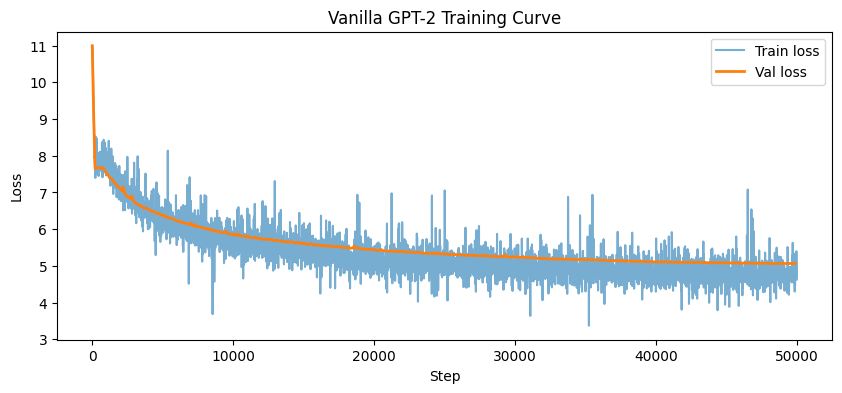

In [ ]:
import matplotlib.pyplot as plt
import json

with open('/content/drive/MyDrive/vanilla_history.json') as f:
    history = json.load(f)

plt.figure(figsize=(10, 4))
plt.plot(history['train_steps'], history['train_loss'], label='Train loss', alpha=0.6)
plt.plot(history['val_steps'], history['val_loss'], label='Val loss', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.title('Vanilla GPT-2 Training Curve')
plt.savefig('/content/drive/MyDrive/vanilla_curve.png')
plt.show()

In [ ]:
@torch.no_grad()
def generate_interleaved(model, prompt_tokens, max_new_tokens, device,
                         temperature=1.0, top_k=None):
    model.eval()
    skip_dist = model.config.lag_behind
    generated = list(prompt_tokens)
    target_len = len(prompt_tokens) + max_new_tokens

    def sample(logits):
        if temperature != 1.0:
            logits = logits / temperature
        if top_k is not None:
            k = min(top_k, logits.size(-1))
            threshold = torch.topk(logits, k).values[-1]
            logits[logits < threshold] = float('-inf')
        return torch.multinomial(F.softmax(logits, dim=-1), 1).item()

    def run_model(tokens):
        seq  = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)
        seq2 = seq.repeat(2, 1)
        logits_fwd, logits_lag, _ = model(seq2)
        return logits_fwd, logits_lag

    count_corr = 0
    while len(generated) < target_len:
        logits_fwd, logits_lag = run_model(generated)
        lag_pos = len(generated) - 1 - skip_dist

        next_token = sample(logits_fwd[0, -1, :].clone())
        generated.append(next_token)

        if lag_pos >= len(prompt_tokens):
            corrected = sample(logits_lag[0, -1, :].clone())
            if corrected != generated[lag_pos]:
                generated[lag_pos] = corrected
                count_corr += 1


    return generated, count_corr

In [ ]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')

prompt = "Once upon a time"
prompt_tokens = enc.encode(prompt)

output_tokens, count_corr = generate_interleaved(
    model, prompt_tokens,
    max_new_tokens=100,
    device=device,
    temperature=0.8,
    top_k=50
)

print(enc.decode(output_tokens))
print(f"Total tokens generated: {len(output_tokens) - len(prompt_tokens)}")
print(f"Total corrections made: {count_corr}")

In [ ]:
import time

def _sample(logits, top_k=1):
    if top_k is not None:
        threshold = torch.topk(logits, min(top_k, logits.size(-1))).values[-1]
        logits[logits < threshold] = float('-inf')
    return torch.multinomial(F.softmax(logits, dim=-1), 1).item()

@torch.no_grad()
def benchmark_vanilla(model, prompt_tokens, max_new_tokens, device, top_k=1):
    model.eval()
    torch.cuda.synchronize()

    # prefill
    start = time.perf_counter()
    logits, kv_caches = model.prefill(prompt_tokens)
    torch.cuda.synchronize()
    prefill_time = time.perf_counter() - start

    generated  = list(prompt_tokens)
    next_token = _sample(logits[0, -1, :].clone(), top_k)
    generated.append(next_token)

    token_latencies = []
    for i in range(max_new_tokens - 1):
        torch.cuda.synchronize()
        t0 = time.perf_counter()

        logits, kv_caches = model.decode_one_token(
            next_token, len(generated) - 1, kv_caches
        )
        next_token = _sample(logits[0, -1, :].clone(), top_k)
        generated.append(next_token)

        torch.cuda.synchronize()
        token_latencies.append(time.perf_counter() - t0)

    return generated, prefill_time, token_latencies

@torch.no_grad()
def benchmark_lag(model, prompt_tokens, max_new_tokens, device, top_k=1):
    model.eval()
    torch.cuda.synchronize()

    # prefill
    start = time.perf_counter()
    logits, kv_caches = model.prefill(prompt_tokens)
    torch.cuda.synchronize()
    prefill_time = time.perf_counter() - start

    generated  = list(prompt_tokens)
    next_token = _sample(logits[0, -1, :].clone(), top_k)
    generated.append(next_token)

    token_latencies  = []
    fwd_latencies    = []
    lag_latencies    = []
    corrections      = 0

    for i in range(max_new_tokens - 1):
        torch.cuda.synchronize()
        t0 = time.perf_counter()

        logits, kv_caches = model.decode_one_token(
            next_token, len(generated) - 1, kv_caches
        )
        next_token = _sample(logits[0, -1, :].clone(), top_k)
        generated.append(next_token)
        torch.cuda.synchronize()
        fwd_latencies.append(time.perf_counter() - t0)

        tl = time.perf_counter()
        logits_lag  = model.lag_correct(generated)
        corrected   = _sample(logits_lag[0, -1, :].clone(), top_k)
        torch.cuda.synchronize()
        lag_latencies.append(time.perf_counter() - tl)

        lag_pos = len(generated) - 1 - model.config.lag_behind
        if lag_pos >= len(prompt_tokens) and corrected != generated[lag_pos]:
            generated[lag_pos] = corrected
            corrections += 1

        torch.cuda.synchronize()
        token_latencies.append(time.perf_counter() - t0)

    return generated, prefill_time, token_latencies, fwd_latencies, lag_latencies, corrections

In [ ]:
import numpy as np

x, _ = test_loader.get_data()
prompt_tokens = x[0, :50].tolist()

MAX_NEW = 200

van_out, van_prefill, van_lat = benchmark_vanilla(
    vanilla_model, prompt_tokens, MAX_NEW, device
)

lag_out, lag_prefill, lag_lat, fwd_lat, lag_only_lat, n_corr = benchmark_lag(
    lag_model, prompt_tokens, MAX_NEW, device
)

print(f"\n{'Metric':<35} | {'Vanilla':>12} | {'Lag':>12}")
print("-" * 63)
print(f"{'Prefill time (ms)':<35} | {van_prefill*1000:>12.2f} | {lag_prefill*1000:>12.2f}")
print(f"{'Avg token latency (ms)':<35} | {np.mean(van_lat)*1000:>12.2f} | {np.mean(lag_lat)*1000:>12.2f}")
print(f"{'Avg fwd latency (ms)':<35} | {'N/A':>12} | {np.mean(fwd_lat)*1000:>12.2f}")
print(f"{'Avg lag latency (ms)':<35} | {'N/A':>12} | {np.mean(lag_only_lat)*1000:>12.2f}")
print(f"{'Total decode time (s)':<35} | {sum(van_lat):>12.3f} | {sum(lag_lat):>12.3f}")
print(f"{'Throughput (tok/s)':<35} | {MAX_NEW/sum(van_lat):>12.1f} | {MAX_NEW/sum(lag_lat):>12.1f}")
print(f"{'Corrections made':<35} | {'N/A':>12} | {n_corr:>12}")
print(f"{'Lag latency growth (first tok ms)':<35} | {'N/A':>12} | {lag_only_lat[0]*1000:>12.2f}")
print(f"{'Lag latency growth (last tok ms)':<35} | {'N/A':>12} | {lag_only_lat[-1]*1000:>12.2f}")


Metric                              |      Vanilla |          Lag
---------------------------------------------------------------
Prefill time (ms)                   |         9.77 |         7.27
Avg token latency (ms)              |         8.27 |        19.16
Avg fwd latency (ms)                |          N/A |         8.27
Avg lag latency (ms)                |          N/A |        10.87
Total decode time (s)               |        1.646 |        3.813
Throughput (tok/s)                  |        121.5 |         52.5
Corrections made                    |          N/A |           58
Lag latency growth (first tok ms)   |          N/A |        10.80
Lag latency growth (last tok ms)    |          N/A |        10.98


In [ ]:
def _extend_cache(kv_caches, model, token, pos):
    x = torch.tensor([[token]], dtype=torch.long, device=model.device)
    pos_emb = model.transformer.wpe(
        torch.tensor([pos], dtype=torch.long, device=model.device)
    )
    h = model.transformer.wte(x) + pos_emb
    new_caches = []
    for layer_block, kv_cache in zip(model.transformer.h, kv_caches):
        h, cache = layer_block(h, future=False, kv_cache=kv_cache)
        new_caches.append(cache)
    return new_caches


def _update_cache_at(model, generated, lag_pos, kv_caches):
    """
    Recompute hidden state and K,V at lag_pos using corrected token
    and cached context from positions 0..lag_pos-1.
    Replace cache at lag_pos, leave all other positions unchanged.
    """
    token = generated[lag_pos]
    x = torch.tensor([[token]], dtype=torch.long, device=model.device)
    pos_emb = model.transformer.wpe(
        torch.tensor([lag_pos], dtype=torch.long, device=model.device)
    )
    h = model.transformer.wte(x) + pos_emb

    new_caches = []
    for layer_idx, (layer_block, kv_cache) in enumerate(
            zip(model.transformer.h, kv_caches)):

        k_cache, v_cache = kv_cache

        k_prefix = k_cache[:, :, :lag_pos, :]
        v_prefix = v_cache[:, :, :lag_pos, :]

        h, new_cache = layer_block(h, future=False,
                                    kv_cache=(k_prefix, v_prefix))

        k_new, v_new = new_cache
        k_full = torch.cat([k_new, k_cache[:, :, lag_pos+1:, :]], dim=2)
        v_full = torch.cat([v_new, v_cache[:, :, lag_pos+1:, :]], dim=2)
        new_caches.append((k_full, v_full))

    return new_caches

In [ ]:
@torch.no_grad()
def benchmark_lag_kv(model, prompt_tokens, max_new_tokens, device,
                      top_k=1, use_kv_lag=False, stale=True):
    model.eval()
    torch.cuda.synchronize()

    # prefill
    start = time.perf_counter()
    logits, kv_caches = model.prefill(prompt_tokens)
    torch.cuda.synchronize()
    prefill_time = time.perf_counter() - start


    next_token = _sample(logits[0, -1, :].clone(), top_k)

    generated = list(prompt_tokens)
    generated.append(next_token)
    kv_caches = _extend_cache(kv_caches, model, next_token,
                                    len(generated)-1)

    token_latencies = []
    fwd_latencies = []
    lag_latencies = []
    corrections = 0

    for i in range(max_new_tokens - 1):
        torch.cuda.synchronize()
        t0 = time.perf_counter()

        tf = time.perf_counter()
        logits, kv_caches = model.decode_one_token(
            next_token, len(generated)-1, kv_caches
        )
        next_token = _sample(logits[0, -1, :].clone(), top_k)
        generated.append(next_token)
        torch.cuda.synchronize()
        fwd_latencies.append(time.perf_counter() - tf)

        tl = time.perf_counter()
        lag_pos = len(generated) - 1 - model.config.lag_behind

        if lag_pos >= len(prompt_tokens):
            logits_lag = model.lag_correct(generated)
            corrected  = _sample(logits_lag[0, -1, :].clone(), top_k)

            if corrected != generated[lag_pos]:
                generated[lag_pos] = corrected
                corrections += 1

                if use_kv_lag:
                    kv_caches = _update_cache_at(
                        model, generated, lag_pos, kv_caches
                    )

                    if not stale:
                        for regen_pos in range(lag_pos + 1, len(generated)):
                            logits, kv_caches = model.decode_one_token(
                                generated[regen_pos - 1],
                                regen_pos - 1,
                                kv_caches
                            )
                            new_token = _sample(logits[0, -1, :].clone(), top_k)
                            generated[regen_pos] = new_token
                            next_token = generated[-1]

        torch.cuda.synchronize()
        lag_latencies.append(time.perf_counter() - tl)
        token_latencies.append(time.perf_counter() - t0)

    return generated, prefill_time, token_latencies, fwd_latencies, lag_latencies, corrections

In [ ]:
test_loader.idx = 0
x, _ = test_loader.get_data()
prompt_tokens = x[0, :50].tolist()
MAX_NEW = 200

# config 1: no KV for lag (current baseline)
out1, pre1, lat1, fwd1, lag1, corr1 = benchmark_lag_kv(
    lag_model, prompt_tokens, MAX_NEW, device,
    use_kv_lag=False, stale=True
)

# config 2: KV + stale
out2, pre2, lat2, fwd2, lag2, corr2 = benchmark_lag_kv(
    lag_model, prompt_tokens, MAX_NEW, device,
    use_kv_lag=True, stale=True
)

# config 3: KV + regenerate (no stale)
out3, pre3, lat3, fwd3, lag3, corr3 = benchmark_lag_kv(
    lag_model, prompt_tokens, MAX_NEW, device,
    use_kv_lag=True, stale=False
)

print(f"\n{'Metric':<35} | {'No KV':>10} | {'KV+Stale':>10} | {'KV+Regen':>10}")
print("-" * 72)
print(f"{'Avg token latency (ms)':<35} | "
      f"{np.mean(lat1)*1000:>10.2f} | "
      f"{np.mean(lat2)*1000:>10.2f} | "
      f"{np.mean(lat3)*1000:>10.2f}")
print(f"{'Avg lag latency (ms)':<35} | "
      f"{np.mean(lag1)*1000:>10.2f} | "
      f"{np.mean(lag2)*1000:>10.2f} | "
      f"{np.mean(lag3)*1000:>10.2f}")
print(f"{'Total decode time (s)':<35} | "
      f"{sum(lat1):>10.3f} | "
      f"{sum(lat2):>10.3f} | "
      f"{sum(lat3):>10.3f}")
print(f"{'Throughput (tok/s)':<35} | "
      f"{MAX_NEW/sum(lat1):>10.1f} | "
      f"{MAX_NEW/sum(lat2):>10.1f} | "
      f"{MAX_NEW/sum(lat3):>10.1f}")
print(f"{'Corrections made':<35} | "
      f"{corr1:>10} | "
      f"{corr2:>10} | "
      f"{corr3:>10}")


Metric                              |      No KV |   KV+Stale |   KV+Regen
------------------------------------------------------------------------
Avg token latency (ms)              |      18.98 |      23.02 |      21.23
Avg lag latency (ms)                |      10.63 |      14.73 |      12.91
Total decode time (s)               |      3.778 |      4.581 |      4.224
Throughput (tok/s)                  |       52.9 |       43.7 |       47.3
Corrections made                    |         58 |        103 |         29
